# CM22009 Semester 2 Coursework (15%): Starter Notebook (Summative)

## Task
Predict hourly bike rental demand (`cnt`) from weather + calendar features using a deep neural network (MLP) trained with backpropagation.

This notebook is your submission. You must fill in all **TODO** sections.

---

## Environment + allowed packages
**Minimum Python:** 3.11 (recommended 3.11 or 3.12)

**Allowed packages:** only those in `requirements.txt`:
- numpy, pandas, matplotlib, scikit-learn, torch, ipykernel (tqdm optional)

**Not allowed:** AutoML or high-level frameworks that remove the need to implement training logic
(e.g., pytorch-lightning, fastai, autogluon, xgboost, catboost, prophet, sktime, gluonts, etc.).

---

## Data download + placement 
You must place the dataset file at:
- `./data/hour.csv`

Folder structure must be:
- `data/hour.csv`

If the notebook cannot find `data/hour.csv`, the submission is incomplete.

---

## How to run (VS Code / local)
1. Install Python 3.11+.
2. Create and activate a venv and install requirements:
   ```bash
   python -m venv .venv
   source .venv/bin/activate   # Windows: .venv\Scripts\activate
   pip install -U pip
   pip install -r requirements.txt
   ```
3. In VS Code: install Python + Jupyter extensions, then select the `.venv` kernel.
   If you see "requires ipykernel", run `pip install ipykernel` and restart.

## How to run (Google Colab)
1. Upload this notebook to Colab.
2. Upload `hour.csv` and ensure it is available at `/content/data/hour.csv`.
3. Install requirements:
   ```python
   !pip install -r requirements.txt
   ```

### Quick download (UCI) — optional convenience
You may download the dataset zip from UCI and extract `hour.csv`.

macOS/Linux:
```bash
mkdir -p data
wget -O bike_sharing.zip https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
unzip -o bike_sharing.zip
# the zip contains a folder named 'Bike-Sharing-Dataset'
cp Bike-Sharing-Dataset/hour.csv data/hour.csv
```

Windows:
- Download the zip in a browser from the UCI page, extract it, then copy `hour.csv` into `data/hour.csv`.
- Alternatively, use WSL and run the macOS/Linux commands.


## Marking map (15 marks total)
Each section below is tagged with **[Marks: x/15]**.

**Dependency rule:** Several sections say **STOP** until previous sections are completed.
The marker will not award marks for later sections if required earlier implementations are missing.


## 0) Setup + sanity checks [Marks: 0/15], i.e, required to run the rest of the code but ungraded
You must set a seed, print versions, and assert `data/hour.csv` exists.

**Dummy output example:**
```
Python: 3.11.x
Torch: 2.x
Dataset found: data/hour.csv
```


In [3]:
# 0) Setup + versions  [Marks: 1/15]
# TODO:
# 1) Import required libraries.
# 2) Set a random seed (for Python, NumPy, and Torch).
# 3) Print your Python and Torch versions.
# 4) Assert that data/hour.csv exists and print a confirmation message.

import os
import random
import platform
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

def seed_everything(seed=SEED):
    """TODO: implement seeding for reproducibility."""
    # HINT: seed random, np.random, torch.manual_seed, torch.cuda.manual_seed_all
    # HINT: set torch.backends.cudnn.deterministic = True and benchmark = False
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

import torch
print("Python:", platform.python_version())
print("Torch:", torch.__version__)

DATA_PATH = "data/hour.csv"
# TODO: assert that the file exists at DATA_PATH
# TODO: print "Dataset found: ..." if it exists
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
print(f"Dataset found: {DATA_PATH}")


Python: 3.11.13
Torch: 2.10.0
Dataset found: data/hour.csv


**Expected output (example):**
- Python: 3.11.7
- Torch: 2.2.1
- Dataset found: data/hour.csv

*(Numbers/versions will differ. The key is: versions print and the dataset path check passes.)*


## 1) Load dataset + minimal Exploratory Data Analysis  [Marks: 0/15], i.e, required to run the rest of the code but ungraded
Load `hour.csv`, parse `dteday`, sort chronologically, and show **one** small EDA table.
Keep EDA minimal: max **1–2 plots total** in the entire notebook.

**Dummy output example:** df.shape printed + head displayed.


In [4]:
# 1) Load + sort chronologically  [Marks: 1/15]
# TODO:
# 1) Read hour.csv from DATA_PATH into df.
df = pd.read_csv(DATA_PATH)
# 2) Convert df["dteday"] to datetime.
df["dteday"] = pd.to_datetime(df["dteday"])
# 3) Sort df by ["dteday", "hr"] and reset index.
df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)
# 4) Print df.shape and display df.head().
print(df.shape)
df.head()
# HINT: pd.read_csv, pd.to_datetime, sort_values, reset_index


(17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


 **Expected output (example):**
- df shape: (17379, 17)

**Preview (df.head()) should look like:**
| instant | dteday     | season | yr | mnth | hr | holiday | weekday | workingday | weathersit | temp | atemp | hum | windspeed | casual | registered | cnt |
|--------:|------------|-------:|---:|-----:|---:|--------:|--------:|-----------:|-----------:|-----:|------:|----:|----------:|-------:|-----------:|----:|
| 1       | 2011-01-01 | 1      | 0  | 1    | 0  | 0       | 6       | 0          | 1          | ...  | ...   | ... | ...       | ...    | ...        | ... |

*(Exact columns and ordering should match the dataset. `dteday` should be datetime and sorted with `hr`.)*


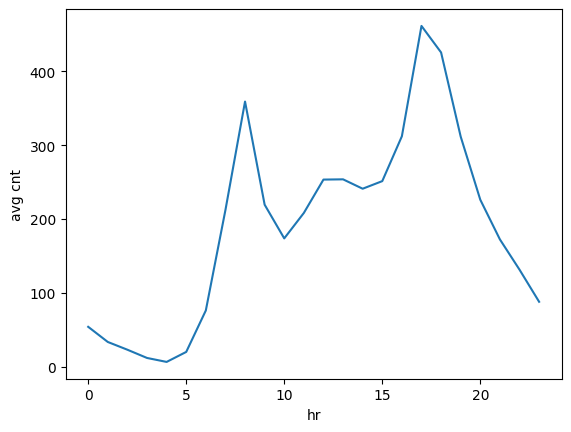

In [5]:
# 1b) OPTIONAL: 1–2 plots total (delete if unused)
avg_by_hr = df.groupby("hr")["cnt"].mean()
plt.figure(); avg_by_hr.plot(); plt.xlabel("hr"); plt.ylabel("avg cnt"); plt.show()


** [Optional section 1(b)] Expected output (example):**
- df shape: (17379, 17)

**Preview (df.head()) should look like:**
| instant | dteday     | season | yr | mnth | hr | holiday | weekday | workingday | weathersit | temp | atemp | hum | windspeed | casual | registered | cnt |
|--------:|------------|-------:|---:|-----:|---:|--------:|--------:|-----------:|-----------:|-----:|------:|----:|----------:|-------:|-----------:|----:|
| 1       | 2011-01-01 | 1      | 0  | 1    | 0  | 0       | 6       | 0          | 1          | ...  | ...   | ... | ...       | ...    | ...        | ... |

*(Exact columns and ordering should match the dataset. `dteday` should be datetime and sorted with `hr`.)*


## 2) Train/Val/Test split + preprocessing (no leakage)  **[Marks: 2.5/15]**
**STOP:** do not proceed to modelling until this section is correct.

**Required split (chronological):** 70% train, 15% val, 15% test.

**Required preprocessing:**
- One-hot encode categorical features.
- Standardise numeric features using **train statistics only**.

**Dummy output example:**
```
Split sizes: 12165 2607 2607
X_train shape: (12165, 61)
X_train | NaN=0 | Inf=0
```


In [6]:
# 2) Split + preprocessing  [Marks: 3/15]
# STOP: you cannot proceed until this section is correct.

# TODO:
# 1) Define label_col, cat_cols, num_cols (see spec).
label_col = "cnt"
cat_cols = ["season","yr","mnth","hr","holiday","weekday","workingday","weathersit"]
num_cols = ["temp","atemp","hum","windspeed"]
keep_cols = cat_cols + num_cols + [label_col]
# 2) Perform chronological split: first 70% train, next 15% val, last 15% test.
train_size = int(round(0.70 * len(df)))
val_size = int(round(0.15 * len(df)))
test_size = int(round(0.15 * len(df)))

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:train_size + val_size + test_size].copy()
# 3) One-hot encode cat_cols on train; apply same columns to val/test (reindex).
train_df_cat = pd.get_dummies(train_df[cat_cols], columns=cat_cols)
val_df_cat = pd.get_dummies(val_df[cat_cols],   columns=cat_cols).reindex(columns=train_df_cat.columns, fill_value=0)
test_df_cat = pd.get_dummies(test_df[cat_cols],  columns=cat_cols).reindex(columns=train_df_cat.columns, fill_value=0)
# 4) Standardise num_cols using TRAIN mean/std only; apply to val/test.
num_means = train_df[num_cols].mean()
num_stds = train_df[num_cols].std()

train_df_num = (train_df[num_cols] - num_means) / num_stds
val_df_num = (val_df[num_cols]   - num_means) / num_stds
test_df_num = (test_df[num_cols]  - num_means) / num_stds
# 5) Concatenate categorical + numeric features to create X_train/X_val/X_test (float32).
X_train = pd.concat([train_df_cat, train_df_num], axis=1).values.astype(np.float32)
X_val = pd.concat([val_df_cat,   val_df_num],   axis=1).values.astype(np.float32)
X_test = pd.concat([test_df_cat,  test_df_num],  axis=1).values.astype(np.float32)
# 6) Create y_train/y_val/y_test from label_col (float32).
y_train = train_df[label_col].values.astype(np.float32)
y_val = val_df[label_col].values.astype(np.float32)
y_test = test_df[label_col].values.astype(np.float32)
# 7) Print split sizes + X_train shape.
print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape:  {y_test.shape}")
# 8) Print finite checks (NaN/Inf counts) for all X and y arrays.
for name, arr in [("X_train",X_train),("X_val",X_val),("X_test",X_test),
                  ("y_train",y_train),("y_val",y_val),("y_test",y_test)]:
    print(f"{name:<7}, NaN= {np.isnan(arr).sum()}, Inf= {np.isinf(arr).sum()}")

# TODO: implement splitting and preprocessing


Split sizes: train=12165, val=2607, test=2607
X_train shape: (12165, 61), y_train shape: (12165,)
X_val shape: (2607, 61), y_val shape:   (2607,)
X_test shape: (2607, 61), y_test shape:  (2607,)
X_train, NaN= 0, Inf= 0
X_val  , NaN= 0, Inf= 0
X_test , NaN= 0, Inf= 0
y_train, NaN= 0, Inf= 0
y_val  , NaN= 0, Inf= 0
y_test , NaN= 0, Inf= 0


**Expected output (example):**
- Split sizes: train=12165, val=2607, test=2607
- X_train shape: (12165, 61) | y_train shape: (12165,)
- X_val shape:   (2607, 61)  | y_val shape:   (2607,)
- X_test shape:  (2607, 61)  | y_test shape:  (2607,)

**Finite checks (example):**
X_train | NaN=0 | Inf=0
X_val   | NaN=0 | Inf=0
X_test  | NaN=0 | Inf=0
y_train | NaN=0 | Inf=0
y_val   | NaN=0 | Inf=0
y_test  | NaN=0 | Inf=0

*(Exact feature count may differ if you change encoding settings, but train/val/test must align and have no NaNs/Infs.)*


## 3) Metrics  **[Marks: 0.5/15]**
Primary metric: **RMSE(log1p)**. Use consistently for baseline and all experiments.


In [7]:
# 3) Metrics  [Marks: 1/15]
# TODO:
# Implement:
# - rmse(y_true, y_pred)
# - rmse_log1p(y_true, y_pred) where y_pred is clipped at >=0 before log1p
# - evaluate_predictions(y_true, y_pred) returning a dict with keys:
#   rmse_log1p, mae_raw, rmse_raw

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmse_log1p(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def evaluate_predictions(y_true, y_pred):
    return {
        "rmse_log1p": round(float(rmse_log1p(y_true, y_pred)), 4),
        "mae_raw": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "rmse_raw": round(float(rmse(y_true, y_pred)), 4)
    }


 **Expected output (example):**
A metrics dict should look like:

{
  "rmse_log1p": 0.35,
  "mae_raw": 50.2,
  "rmse_raw": 80.7
}

*(Values will differ. The key is: returns a dict with exactly these keys and numeric values.)*


## 4) Baseline model (required)  **[Marks: 0.5/15]**
**STOP:** baseline required before deep learning.


In [8]:
# 4) Baseline (Ridge)  [Marks: 1/15]
# STOP: do not proceed until you have a baseline.

# TODO:
# 1) Fit a Ridge regression baseline on (X_train, y_train).
from sklearn.linear_model import Ridge
baseline = Ridge()
baseline.fit(X_train, y_train)
# 2) Predict on X_val.
baseline_val_pred = baseline.predict(X_val)
# 3) Compute metrics using evaluate_predictions(y_val, baseline_val_pred).
metrics = evaluate_predictions(y_val, baseline_val_pred)
# 4) Print "Baseline VAL: ..." with the metrics dict.
print(f"Baseline VAL: {metrics}")

# TODO: implement baseline


Baseline VAL: {'rmse_log1p': 1.0436, 'mae_raw': 110.6162, 'rmse_raw': 141.6182}


**Expected output (example):**
Baseline VAL: {'rmse_log1p': 0.44, 'mae_raw': 70.1, 'rmse_raw': 105.8}

*(Values will differ. The key is: baseline runs, prints a dict with the three metrics on VAL.)*


## 5) Implement the deep MLP (>=3 hidden layers)  **[Marks: 2/15]**
**STOP:** Sections 6–9 depend on this.

You must implement `MLPRegressor` with >=3 hidden layers and activations.


In [9]:
# 5) Deep MLP model (TODO)  [Marks: 2/15]
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLPRegressor(nn.Module):
    def __init__(self, in_dim, hidden=(256,128,64), activation="relu", dropout=0.0):
        super().__init__()
        layers = []
        
        if activation == "relu":
            act_fn = nn.ReLU
        else:
            act_fn = nn.Identity

        prev_dim = in_dim
        # TODO: build layers (len(hidden) must be >= 3)
        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)


    def forward(self, x):
        # TODO
        #return self.network(x).squeeze(-1)
        return self.network(x)

# After implementing:
model = MLPRegressor(in_dim=X_train.shape[1], hidden=(256,128,64))
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))


Device: cpu
MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=61, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 57089


**Expected output (example):**
- Printed model summary (any readable representation is fine)
- Total parameters: 4xxxx

**Minimum requirement reminders:**
- Must be a **deep** MLP (≥ 3 hidden layers)
- Output shape must match target shape (one prediction per row)

*(Exact parameter count differs depending on your layer sizes.)*


## 6) Implement training loop (backprop + optimiser)  **[Marks: 2/15]**
**STOP:** Sections 7–9 depend on this.

Must support: Adam + Momentum-SGD, MSE + MAE, validation each epoch, early stopping, stability (e.g., grad clipping).


In [42]:
# 6) Training utilities + train_model (TODO)  [Marks: 3/15]
from torch.utils.data import TensorDataset, DataLoader

@torch.no_grad()
def predict(model, X, batch_size=1024):
    """
    Required: batched prediction that works when the final batch is smaller.
    DO NOT use np.vstack on 1D arrays (it will fail on the last batch).
    """
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        yb = model(xb).detach().cpu().numpy()
        preds.append(yb.reshape(-1))  # force 1D
    return np.concatenate(preds, axis=0)


def train_model(cfg, X_tr, y_tr, X_va, y_va):
    # TODO: implement training loop + early stopping + stability guards
    
    model = MLPRegressor(in_dim=X_tr.shape[1], hidden=cfg["hidden"], activation=cfg["activation"], dropout=cfg["dropout"])
    
    if cfg["optimizer"] == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=1e-5)

    if cfg["loss"] == "mse":
        loss_fn = nn.MSELoss()
    else:
        loss_fn = nn.L1Loss()

    X_train = torch.from_numpy(X_tr)
    y_train = torch.from_numpy(y_tr)
    dataset = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=cfg["batch_size"], shuffle=True)

    best_val_loss = float("inf")
    best_weights = None
    patience_counter = 0

    epoch_history = []

    for epoch in range(cfg["max_epochs"]):

        model.train()

        for xb, yb in dataloader:
            
            optimizer.zero_grad()

            preds = model(xb).reshape(-1)
            
            loss = loss_fn(preds, yb)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        
        train_preds = predict(model, X_tr)
        train_metrics = evaluate_predictions(y_tr, train_preds)

        val_preds = predict(model, X_va)
        val_metrics = evaluate_predictions(y_va, val_preds)
        val_rmse_log1p = val_metrics["rmse_log1p"]

        epoch_history.append({"epoch": epoch+1, 
                              "train_rmse_log1p": train_metrics["rmse_log1p"], 
                              "train_mae_raw": train_metrics["mae_raw"], 
                              "train_rmse_raw": train_metrics["rmse_raw"], 
                              "val_rmse_log1p": val_metrics["rmse_log1p"], 
                              "val_mae_raw": val_metrics["mae_raw"], 
                              "val_rmse_raw": val_metrics["rmse_raw"]})

        if val_rmse_log1p < best_val_loss:
            best_val_loss = val_rmse_log1p
            best_weights = {k: v for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if cfg.get("early_stopping", False) and cfg.get("patience", 0) > 0:
            if patience_counter >= cfg["patience"]:
                print(f"Early stop reached at epoch: {epoch+1} | best_val_rmse_log1p: {best_val_loss:.4f}")
                break
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1} val_rmse_log1p: {val_metrics['rmse_log1p']:.4f}")

    model.load_state_dict(best_weights)
    
    history_df = pd.DataFrame(epoch_history)
    return model, history_df

    

**Expected output (example):**
During training, you should see periodic progress logs such as:

epoch 20 val rmse_log1p 0.41
epoch 40 val rmse_log1p 0.36
Early stop @ epoch 63 | best rmse_log1p 0.33

*(Exact wording can differ, but you must show training progress and validation metric over epochs.)*


## 7) Sanity check: tiny overfit test (required)  **[Marks: 0.5/15]**
Train on 256 samples and show training error drops substantially.


In [51]:
# 7) Tiny overfit test (TODO)  [Marks: 1/15]
# STOP: requires Sections 5 and 6 implemented.
# TODO: use first 256 training samples, disable early stopping, confirm training error drops.
sanity_check_cfg = {
    "hidden": (256, 128, 64),
    "activation": "relu",
    "dropout": 0.0,
    "optimizer": "adam",
    "loss": "mse",
    "lr" : 1e-3,
    "batch_size": 64,
    "max_epochs": 200,
    "early_stopping": False,
    "patience": 0
}

model, history_df = train_model(sanity_check_cfg, X_train[:256], y_train[:256], X_val, y_val)

history_df[["epoch", "train_rmse_log1p", "train_mae_raw", "train_rmse_raw"]].iloc[19::20]

Epoch 20 val_rmse_log1p: 2.0136
Epoch 40 val_rmse_log1p: 1.2128
Epoch 60 val_rmse_log1p: 1.1427
Epoch 80 val_rmse_log1p: 1.1070
Epoch 100 val_rmse_log1p: 1.1015
Epoch 120 val_rmse_log1p: 1.0884
Epoch 140 val_rmse_log1p: 1.0702
Epoch 160 val_rmse_log1p: 1.0742
Epoch 180 val_rmse_log1p: 1.0669
Epoch 200 val_rmse_log1p: 1.0550


,epoch,train_rmse_log1p,train_mae_raw,train_rmse_raw
19,20,1.2621,31.8327,42.4464
39,40,0.7632,16.3060,21.5559
59,60,0.3605,6.6435,9.2833
79,80,0.2594,4.5029,6.2958
99,100,0.2324,3.3997,5.1137
119,120,0.2137,2.6045,3.9300
139,140,0.2078,2.4953,3.4726
159,160,0.1874,1.9614,2.8679
179,180,0.1633,1.2465,2.0544
199,200,0.1369,0.8926,1.5861


**Expected output (example):**
Tiny overfit metrics (train on small subset): 
{'rmse_log1p': 0.05, 'mae_raw': 5.2, 'rmse_raw': 8.1}

And a small tail of the training history table like:

| epoch | rmse_log1p | mae_raw | rmse_raw |
|------:|-----------:|--------:|---------:|
| 180   | 0.06       | 6.0     | 9.0      |
| 200   | 0.05       | 5.2     | 8.1      |

*(Your overfit result doesn’t need to be exactly this low, but it should clearly improve a lot—otherwise something is wrong.)*


## 8) Controlled experiments (minimum 4 runs) + results table  **[Marks: 3/15]**
**STOP:** requires Sections 5–6.

Minimum grid requirements:
- Optimisers: Adam AND Momentum-SGD
- Losses: MSE AND MAE
- Learning rates: >=2 distinct values across runs
- Regularisation: >=1 method (early stopping is acceptable)

You must produce `results_df` and store `histories` for learning curves.


In [56]:
# 8) Experiments (TODO)  [Marks: 2/15]
# STOP: You should only start this section after Sections 5–7 work.

# OUTPUT REQUIRED IN THIS SECTION:
# 1) A Python list named `configs` with >= 4 experiment dictionaries.

configs = []

optimizers = ["adam", "sgd"]
losses = ["mse", "mae"]
lrs = [1e-3,3e-4]

for optimizer in optimizers:
    for loss in losses:
            for lr in lrs:
                    config = {
                        "hidden": (256, 128, 64), 
                        "activation": "relu",
                        "dropout": 0.2,
                        "optimizer": optimizer,
                        "loss": loss,
                        "lr": lr,
                        "batch_size": 64,
                        "max_epochs": 100,
                        "early_stopping": True,
                        "patience": 5,
                        }
                    configs.append(config)


# 2) A loop that runs each config and creates:
#    - `models`     : dict mapping run_name -> trained model
#    - `histories`  : dict mapping run_name -> per-epoch history DataFrame (must include columns: epoch, rmse_log1p)
#    - `results_df` : DataFrame comparing validation metrics across runs, sorted by rmse_log1p ascending

models = {}
histories = {}
results = []

for i, cfg in enumerate(configs):

    run_name = f"{cfg['optimizer']}_{cfg['loss']}_lr{cfg['lr']}"

    model, history_df = train_model(cfg, X_train, y_train, X_val, y_val)

    models[run_name] = model
    histories[run_name] = history_df[["epoch", "val_rmse_log1p", "val_mae_raw", "val_rmse_raw"]]
  
    last_metrics = history_df[["epoch", "val_rmse_log1p", "val_mae_raw", "val_rmse_raw"]].iloc[-1].to_dict()

    results.append({
        "run": run_name,
        "optim": cfg["optimizer"],
        "loss": cfg["loss"],
        "lr": cfg["lr"],
        "regularisation": "early_stopping, dropout, L2",
        "val_rmse_log1p": last_metrics["val_rmse_log1p"],
        "val_mae_raw": last_metrics["val_mae_raw"],
        "val_rmse_raw": last_metrics["val_rmse_raw"]
    })

# 3) Display `results_df`.

results_df = pd.DataFrame(results).sort_values("val_rmse_log1p").reset_index(drop=True)

results_df

# CONTROLLED EXPERIMENTS REQUIREMENT (minimum 4 runs):
# - Hold constant across runs: data split, preprocessing, architecture (hidden dims), batch_size, epochs,
#   early_stopping settings (early_stopping=True, patience fixed), and metric (RMSE(log1p)).
# - Vary across runs: optimiser (Adam vs Momentum-SGD) AND loss (MSE vs MAE).
# - Use stable LRs (e.g., Adam ~1e-3; Momentum may need smaller, e.g., 3e-4) and include gradient clipping.
#
# NOTE: You MUST use validation metrics (not test) to compare runs and select the best run.


Early stop reached at epoch: 20 | best_val_rmse_log1p: 0.4405
Epoch 20 val_rmse_log1p: 0.4435
Early stop reached at epoch: 29 | best_val_rmse_log1p: 0.4044
Early stop reached at epoch: 19 | best_val_rmse_log1p: 0.2965
Epoch 20 val_rmse_log1p: 0.3347
Early stop reached at epoch: 40 | best_val_rmse_log1p: 0.2888
Epoch 20 val_rmse_log1p: 1.0794
Early stop reached at epoch: 39 | best_val_rmse_log1p: 0.8899
Early stop reached at epoch: 15 | best_val_rmse_log1p: 1.2593
Epoch 20 val_rmse_log1p: 0.8803
Epoch 40 val_rmse_log1p: 0.6370
Early stop reached at epoch: 54 | best_val_rmse_log1p: 0.5302
Epoch 20 val_rmse_log1p: 1.1946
Epoch 40 val_rmse_log1p: 1.1028
Epoch 60 val_rmse_log1p: 0.9232
Epoch 80 val_rmse_log1p: 0.8151
Epoch 100 val_rmse_log1p: 0.7307


,run,optim,loss,lr,regularisation,val_rmse_log1p,val_mae_raw,val_rmse_raw
0,adam_mae_lr0.0003,adam,mae,0.0003,"early_stopping, dropout, L2",0.2900,40.1068,63.8760
1,adam_mae_lr0.001,adam,mae,0.0010,"early_stopping, dropout, L2",0.3374,42.1817,64.1583
2,adam_mse_lr0.0003,adam,mse,0.0003,"early_stopping, dropout, L2",0.4126,49.0901,72.2384
3,adam_mse_lr0.001,adam,mse,0.0010,"early_stopping, dropout, L2",0.4628,48.6611,70.6514
4,sgd_mae_lr0.001,sgd,mae,0.0010,"early_stopping, dropout, L2",0.5344,67.5445,92.5599
5,sgd_mae_lr0.0003,sgd,mae,0.0003,"early_stopping, dropout, L2",0.7307,87.3692,119.1446
6,sgd_mse_lr0.001,sgd,mse,0.0010,"early_stopping, dropout, L2",0.8949,87.8332,109.8067
7,sgd_mse_lr0.0003,sgd,mse,0.0003,"early_stopping, dropout, L2",1.2607,155.0311,205.0096


**Dummy example of the required `results_df` output format (your numbers will differ):**

| run             | optim    | loss | lr     | regularisation | rmse_log1p | mae_raw | rmse_raw |
| --------------- | -------- | ---- | ------ | -------------- | ---------- | ------- | -------- |
| adam_mae_lr1e-3 | adam     | mae  | 0.0010 | early_stopping | 0.3184     | 46.2    | 74.9     |
| adam_mse_lr1e-3 | adam     | mse  | 0.0010 | early_stopping | 0.3327     | 48.0    | 77.8     |
| mom_mae_lr3e-4  | momentum | mae  | 0.0003 | early_stopping | 0.3519     | 52.3    | 83.6     |
| mom_mse_lr3e-4  | momentum | mse  | 0.0003 | early_stopping | 0.3688     | 54.1    | 86.9     |


### 8b) Experimental design notes (markdown)  **[Marks: 1/15]**
Write 150–250 words explaining what you held constant vs varied, and why RMSE(log1p) is used.


**Expected format (example):**
A single paragraph of 150–250 words that explicitly states:
- what you held constant,
- what you varied (optimiser + loss),
- why RMSE(log1p) is used for counts.

*(Your wording will differ. Keep it concise and specific to your runs.)*


My experiments evaluated three variables: the optimiser, the loss function, and the learning rate. Using a full factorial design across these three factors, 8 configurations were generated. The network was trained with Adam, SGD, MSE, and MAE, using learning rates of 1e-3 and 3e-4. MSE and MAE were both included as they differ in sensitivity to outliers, making their comparison meaningful given the skewed target distribution. Adam and SGD were selected because they represent adaptive and fixed learning-rate optimisation strategies, making their comparison particularly informative.

Regularisation techniques were held constant throughout the experiment. Early stopping patience remained at 5, dropout at 0.2, and L2 weight decay at 1e-5. Stability and training parameters remained constant: a fixed network architecture (256-128-64), a batch size of 64, a maximum of 100 epochs, a gradient clipping norm of 1, and SGD momentum of 0.9. The purpose of holding these constants is to isolate the effects of the varied factors, ensuring that any differences in validation performance can be attributed directly to the optimiser, loss function, or learning rate. These values were chosen through informal exploratory runs before the formal experiments, and produced stable training dynamics across trial runs.

The distribution of the bike-count dataset drives the choice of RMSE(log1p). As evidenced by Q1's EDA, the bike counts are right-skewed, with a peak around 17:00. This means that a raw RMSE score would be heavily influenced by these high-demand hours. Including log1p compresses the scale, making errors comparable across low- and high-demand periods.


## 9) Plot learning curves + choose final model  **[Marks: 2/15]**

You must produce the following outputs in cells 9a and 9b.

**9a (plot cell):**
1) Identify the **best 2 runs** using **validation RMSE(log1p)** from `results_df` (lowest is best).
2) Plot **validation RMSE(log1p) vs epoch** for those 2 runs on the **same figure**.
3) The plot must include:
- x-axis label: `epoch`
- y-axis label: `val RMSE(log1p)`
- legend with the **run names**

**9b (selection + test once):**
1) Select the **single best run** using **validation RMSE(log1p) only** (lowest wins).
2) Print one line exactly in this format:  
`Final selected run (by validation only): <run_name> | VAL rmse_log1p=<value>`
3) Evaluate the selected model on the **test set exactly once** and print the test metrics dict.
4) Print one final line:  
`Test evaluated ONCE after selection.`
5) Do **NOT** compute test metrics for multiple runs.


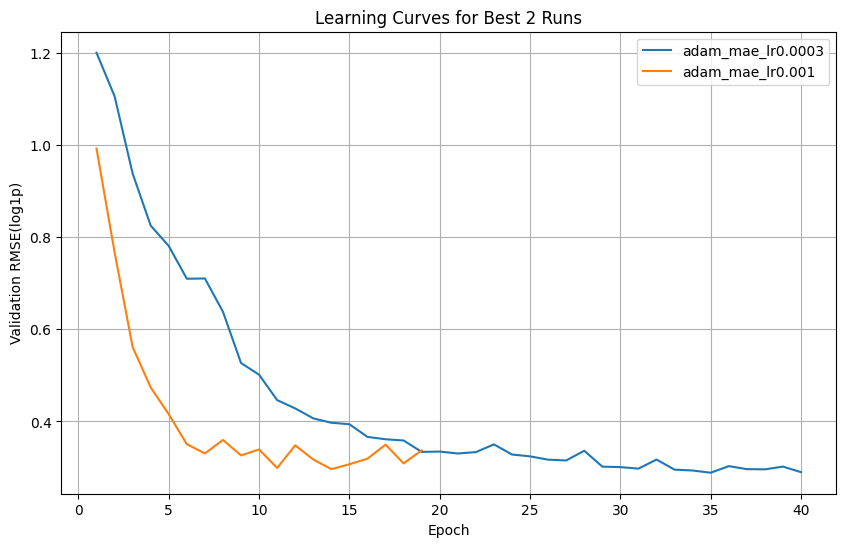

In [57]:


# 9a) Plot learning curves (required output)
#  TODO
# Output required in this cell:
# 1) Compute best 2 runs based on validation RMSE(log1p) from results_df (lowest is best).
best_2_runs = results_df.nsmallest(2, "val_rmse_log1p")["run"].values
# 2) Plot val RMSE(log1p) vs epoch for those 2 runs on the same figure.
plt.figure(figsize=(10, 6))
for run in best_2_runs:
    history = histories[run]
    plt.plot(history["epoch"], history["val_rmse_log1p"], label=run)
# 3) Must include: x-axis 'epoch', y-axis 'val RMSE(log1p)', legend with run names.
plt.xlabel("Epoch")
plt.ylabel("Validation RMSE(log1p)")
plt.title("Learning Curves for Best 2 Runs")
plt.legend()
plt.grid()
plt.show()

 **Expected output (example):**
A single plot figure showing **two curves**:
- x-axis: epoch
- y-axis: val RMSE(log1p)
- legend: two run names (e.g., `adam_mae_lr1e-3`, `adam_mse_lr1e-3`)

*(No table required here—just the plot with correct labels and legend.)*


In [58]:
# 9b) Final selection + test report (TODO)  [Marks: 1/15]
# TODO: compute test metrics once for your chosen model
best_run = results_df.iloc[0]["run"]
best_val_rmse_log1p = float(results_df.iloc[0]["val_rmse_log1p"])
best_model = models[best_run]

print(f"Final selected run (by validation only): {best_run} | VAL rmse_log1p={best_val_rmse_log1p:.6f}")

test_pred = predict(best_model, X_test)
best_test_metrics = evaluate_predictions(y_test, test_pred)
print("TEST metrics:", best_test_metrics)

print("Test evaluated ONCE after selection.")


Final selected run (by validation only): adam_mae_lr0.0003 | VAL rmse_log1p=0.290000
TEST metrics: {'rmse_log1p': 0.5152, 'mae_raw': 57.0914, 'rmse_raw': 80.3018}
Test evaluated ONCE after selection.


 **Expected output (example):**
Final selected run (by validation only): adam_mae_lr2e-4 | VAL rmse_log1p=0.318400
TEST metrics: {'rmse_log1p': 0.3351, 'mae_raw': 48.7, 'rmse_raw': 78.4}
Test evaluated ONCE after selection.

*(Values will differ. The key is: one selected run, one test evaluation, correct printed lines.)*


## 10) Error analysis (top 10 errors)  **[Marks: 1/15]**
Create a table of the top-10 absolute errors on the test set and add 2–4 bullet explanations.


In [15]:
# 10) Error analysis template (TODO)  [Marks: 1/15]
# Output required in this cell:
# 1) Compute absolute errors on the TEST set: abs(y_test - pred_test_clipped)
test_pred = predict(best_model, X_test)
test_pred_clipped = np.clip(test_pred, a_min=0, a_max=None)
abs_errors = np.abs(y_test - test_pred_clipped)
# 2) Find the top 10 largest absolute errors.
top_10_indices = np.argsort(abs_errors)[-10:]  
top_10_rows = test_df.iloc[top_10_indices].copy()
# 3) Create a DataFrame named analysis_df with exactly these columns:
#    ["dteday","hr","weathersit","temp","hum","windspeed","cnt","pred_cnt","abs_error"]
top_10_rows["pred_cnt"] = test_pred_clipped[top_10_indices]
top_10_rows["abs_error"] = abs_errors[top_10_indices]
analysis_df = top_10_rows[["dteday", "hr", "weathersit", "temp", "hum", "windspeed", "cnt", "pred_cnt", "abs_error"]]
# 4) Display analysis_df (top 10 errors, sorted descending by abs_error).
#
analysis_df = analysis_df.sort_values(by="abs_error", ascending=False)
analysis_df
# NOTE: pred_cnt must be clipped to >= 0 for counts.



,dteday,hr,weathersit,temp,hum,windspeed,cnt,pred_cnt,abs_error
15661,2012-10-19,18,1,0.56,0.83,0.1045,233,659.823669,426.823669
16454,2012-11-23,8,1,0.24,0.87,0.0896,94,508.187988,414.187988
16439,2012-11-22,17,1,0.44,0.35,0.0000,109,513.515015,404.515015
16464,2012-11-23,18,2,0.46,0.44,0.0000,208,608.957825,400.957825
16440,2012-11-22,18,1,0.40,0.43,0.0000,70,453.765350,383.765350
15890,2012-10-30,19,2,0.50,0.68,0.1940,115,484.702087,369.702087
17196,2012-12-24,8,1,0.22,0.69,0.0000,66,422.450531,356.450531
16463,2012-11-23,17,2,0.48,0.39,0.0896,300,649.811462,349.811462
15228,2012-10-01,17,3,0.56,0.60,0.2537,856,507.010712,348.989288
15243,2012-10-02,8,3,0.60,0.88,0.0000,134,481.023956,347.023956


**Expected output (example):**
A displayed `analysis_df` table of the **top 10 largest absolute errors**, with columns:

[dteday, hr, weathersit, temp, hum, windspeed, cnt, pred_cnt, abs_error]

Example format:

| dteday     | hr | weathersit | temp | hum | windspeed | cnt | pred_cnt | abs_error |
|------------|---:|-----------:|-----:|----:|----------:|----:|---------:|----------:|
| 2012-07-xx | 17 | 2          | ...  | ... | ...       | 9xx | 6xx      | 3xx       |
| ...        | .. | ..         | ...  | ... | ...       | ... | ...      | ...       |

*(Exact rows/values differ. The key is correct columns + 10 rows sorted by abs_error.)*


### 10b) Error analysis commentary (markdown)
TODO: add 2–4 bullets interpreting the top errors.


**Expected format (example):**
2–4 bullet points interpreting patterns in the top-error rows. For example:
- Peaks (commute hours) are often underpredicted.
- Certain weather categories show larger errors.
- Holiday/weekend patterns differ from weekdays.
- Some errors likely reflect unobserved factors (events, disruptions).

*(Your bullets must refer to what you see in your table.)*

- All 10 of the biggest errors occur either at 8am, or around 6pm, which are standard times for commuters heading to and from work. These periods cause high levels of demand, as we saw from the graph in Q1, and the model has clearly learned to predict high-demand for these times. However, these specific days have unusually low numbers and have been vastly over-predicted by the model (seen by the difference between cnt and pred_cnt). These anomalous data values do not conform to the data's typical demand patterns, and as such lead to high levels of error with the model being unable to identify these days as unusual and adjust its predictions accordingly.

- Alongside the obvious Christmas Eve entry, we see the repeated occurrence of 2012-11-22 and 2012-11-23, both exhibiting notably low counts. Upon researching the significance of these dates, I found that the 22nd November 2012 fell on a Thursday - the date of the American holiday Thanksgiving - with the 23rd forming part of the public holiday weekend. This clearly explains the unusually low levels of transport on these dates. This highlights a key limitation of the dataset's 'holiday' feature: as a simple binary indicator, it fails to provide the model with information regarding the true effect of holidays on demand patterns. These residuals are largely unavoidable, given the model was trained on one year of data only, and thus has no prior exposure to the demand levels recorded on these specific holidays.

- Interestingly, 8 out of the 10 greatest errors occur on days with weathersit values of 1 or 2, with 5 out of 10 also recording a windspeed of 0 — conditions that collectively suggest near-optimal cycling weather. Despite this, actual counts remains down on these dates, suggesting the model has become over-reliant on favourable weather as a positive demand signal. These aggressive predictions of high demand given these weather conditions has resulted in high residuals on certain days such as the previously mentioned holidays, and anomalous entries like 2012-10-02 (a day that likely saw high transport disruption), with the model failing to consider broader contextual factors when presented with good weather conditions.

- With the chronological split of the dataset, model training takes place using days across 2011, whilst performance is tested across 2012. Interestingly, all of the 10 greatest errors occurred from September 2012 onwards, suggesting that there is a change in bike count distribution with time. It appears that, as time goes on, the bike count distribution shifts, with the average numbers increasing from 143.79 to 234.67. This is known as non-stationary data, a key time-series property exhibited by this dataset.


## 11) Reflection & limitations  **[Marks: 1/15]**
Write 400–600 words referencing your experiments.


**Expected format (example):**
400–600 words that:
- references your experiment runs (Section 8 results),
- explains what worked/didn’t and why,
- discusses limitations (data/features/model),
- proposes plausible next steps (without adding new experiments).

*(No code output required—this is assessed from your writing + references to your results.)*


## 12) Required JSON summary  [Marks: 0/15], the summary will be used to corroborate your results and update the marks on Moodle. 
Generate `submission_summary.json` (marker will check it).


In [63]:
# 12) submission_summary.json (TODO)  [Marks: 1/15]
import json, platform, torch

"""
# Derive best validation metrics from results_df (already computed on val)
best_row = results_df.loc[results_df["run"] == best_run].iloc[0]

best_val_metrics = {
    "rmse_log1p": float(best_row["rmse_log1p"]),
    "mae_raw": float(best_row["mae_raw"]),
    "rmse_raw": float(best_row["rmse_raw"]),
}

"""
submission_summary = {
  "student_id": "REPLACE_WITH_USERID",
  "python_version": platform.python_version(),
  "torch_version": torch.__version__,
  "split_sizes": {"train": int(len(train_df)), "val": int(len(val_df)), "test": int(len(test_df))},
  "baseline_metrics_val": {},
  "tiny_overfit_metrics_train": {},
  "best_run_name": None,
  "best_val_metrics": {},
  "best_test_metrics": best_test_metrics,
  "experiments": []
}
with open("submission_summary.json","w") as f:
    json.dump(submission_summary, f, indent=2)
print("Wrote submission_summary.json")


Wrote submission_summary.json


**Expected output (example):**
Wrote submission_summary.json

And the JSON file should contain keys similar to:

{
  "student_id": "YOUR_USER_ID",
  "python_version": "3.11.x",
  "torch_version": "2.x.x",
  "split_sizes": {"train": 12165, "val": 2607, "test": 2607},
  "baseline_metrics_val": {"rmse_log1p": 0.xx, "mae_raw": xx.x, "rmse_raw": xx.x},
  "tiny_overfit_metrics_train": {"rmse_log1p": 0.xx, "mae_raw": xx.x, "rmse_raw": xx.x},
  "best_run_name": "adam_mae_lr1e-3",
  "best_val_metrics": {...},
  "best_test_metrics": {...},
  "experiments": [ ... list of dicts ... ]
}

*(Exact numbers differ. The key is: file is written and contains the required fields.)*
